In [89]:
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import ( train_test_split, KFold, StratifiedKFold, LeaveOneOut, cross_val_score)
from sklearn.datasets import (make_regression,make_classification,load_iris, make_blobs)
from sklearn.linear_model import (LinearRegression, LogisticRegression, Ridge, Lasso)
from sklearn.metrics import mean_squared_error, accuracy_score , mean_absolute_error, r2_score  # works only discrete data
from sklearn.metrics import classification_report    #works only continuous data

MAE: 1.3204947290887563
MSE: 2.8419085668241983
Root MSE : 1.6857961225558085
R² Score: 0.9719163026975668


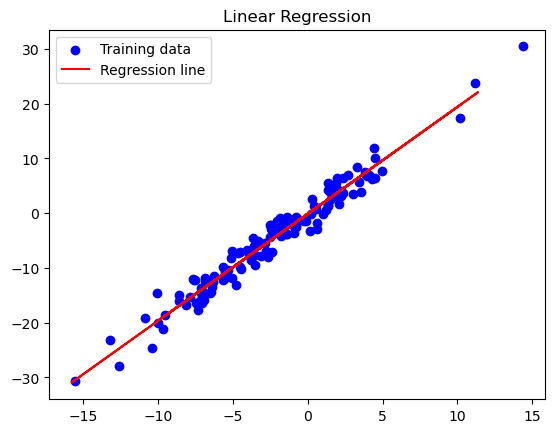

In [90]:
#Linear Regression
X, Y = make_blobs(n_samples=200, centers=1, n_features=1, cluster_std=5, random_state=42) #creates data

y = X.squeeze() * 2 + np.random.randn(200) * 2    #makes input from make blob into continuous
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35, random_state=42)
lr = LinearRegression()   #creates model
lr.fit(X_train, y_train) #trains the model
y_pred = lr.predict(X_test)  #predicts using the model

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("Root MSE :", math.sqrt(mse))
print("R² Score:", r2_score(y_test, y_pred))

plt.scatter(X_train, y_train, color="blue", label="Training data")
plt.plot(X_test, y_pred, color="red", label="Regression line")
plt.title("Linear Regression")
plt.legend()
plt.show()

Logistic Regression Accuracy: 0.9571428571428572
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        29
           1       0.97      0.95      0.96        41

    accuracy                           0.96        70
   macro avg       0.95      0.96      0.96        70
weighted avg       0.96      0.96      0.96        70



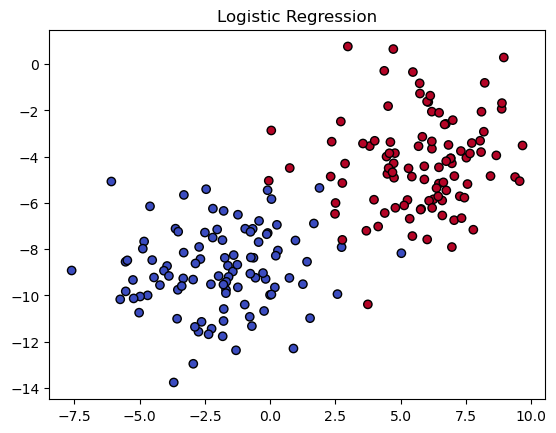

In [91]:
#Logistic Regression
X, y = make_blobs(
    n_samples=200,
    centers=2,          
    n_features=2,
    cluster_std=2.0,
    random_state=40
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=43
)

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

report_lr = classification_report(y_test,y_pred)
print(report_lr)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',edgecolors='k')
plt.title("Logistic Regression")
plt.show()

MAE: 0.2470126644708158
MSE: 0.09697537334636853
Root MSE : 0.3114086918285495
R² Score: 0.8628144678696508


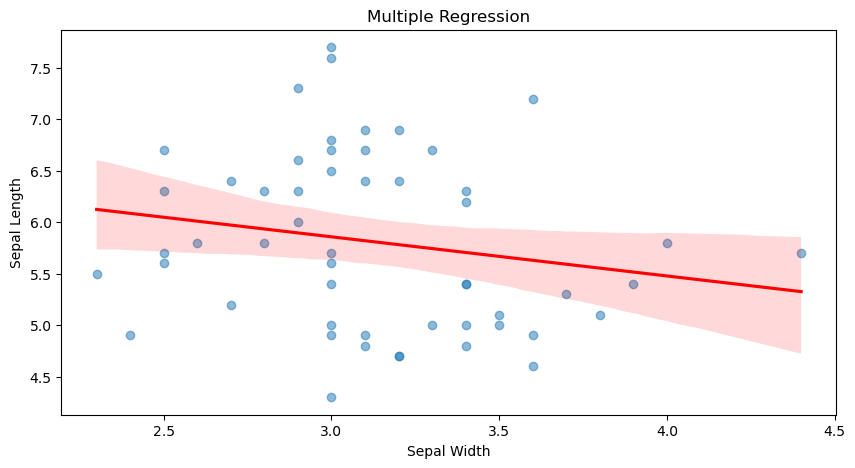

In [92]:
#Multiple Regression (multiple fields)
iris = load_iris()
X = iris.data[:, 1:]   # sepal width, petal length, petal width
y = iris.data[:, 0]    # sepal length (continuous target)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.35, random_state=24)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("Root MSE :", math.sqrt(mse))
print("R² Score:", r2_score(y_test, y_pred))

plt.figure(figsize=(10, 5))
sns.regplot(
    x=X_test[:, 0],
    y=y_test,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title("Multiple Regression")
plt.xlabel("Sepal Width")
plt.ylabel("Sepal Length")
plt.show()


In [93]:
X_multi, y_multi = make_regression(
    n_samples=200, n_features=3, noise=15, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)
y_pred = lr_multi.predict(X_test)

print("Multiple Linear Regression MSE:",
      mean_squared_error(y_test, y_pred))


X_cls, y_cls = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred))

# K-Fold Cross Validation
kf = KFold(n_splits=5)
kf_scores = cross_val_score(
    LinearRegression(), X_multi, y_multi,
    scoring="neg_mean_squared_error", cv=kf
)
print("K-Fold CV MSE:", -kf_scores.mean())

# Stratified K-Fold (for classification)
skf = StratifiedKFold(n_splits=5)
skf_scores = cross_val_score(
    LogisticRegression(), X_cls, y_cls, cv=skf
)
print("Stratified CV Accuracy:", skf_scores.mean())

# Leave-One-Out Cross Validation
loo = LeaveOneOut()
loo_scores = cross_val_score(
    LinearRegression(), X_multi, y_multi,
    scoring="neg_mean_squared_error", cv=loo
)
print("LOOCV MSE:", -loo_scores.mean())


# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print("Ridge Regression MSE:", mean_squared_error(y_test, y_pred))

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print("Lasso Regression MSE:", mean_squared_error(y_test, y_pred))

Multiple Linear Regression MSE: 298.4033866292119
Logistic Regression Accuracy: 0.9
K-Fold CV MSE: 250.13985272468435
Stratified CV Accuracy: 0.9266666666666665
LOOCV MSE: 253.09054696789644
Ridge Regression MSE: 0.07470272241462732
Lasso Regression MSE: 0.08307444607059794
